## Configuração

`[ENTREGAVEL + REAL]`

Centralizar paths e validar que D3 existe antes de treinar, falha rápida é melhor que erro silencioso no meio do treinamento. MODEL_OUT separado de CORPUS_OUT organiza artefatos textuais e de modelo para deploy no RPi5.

D3 vem do pipeline NB9: 

2.760.117 instâncias brutas 
→ 3.115 frases únicas 
→ top-50 por classe 
→ 100 frases balanceadas.

CHARTS_OUT centraliza todos os PNGs do NB11 junto com NB9/NB10 para inspeção visual conjunta.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

# Paths - mesma raiz do NB9 e NB10
CORPUS_OUT = Path('../../data/processed/mimic-iv-ecg/corpus')
MODEL_OUT = Path('../../data/processed/mimic-iv-ecg/corpus/model')
CHARTS_OUT = Path('../../data/processed/mimic-iv-ecg/eda_charts')
MODEL_OUT.mkdir(parents=True, exist_ok=True)
CHARTS_OUT.mkdir(parents=True, exist_ok=True)

D3_PATH = CORPUS_OUT / 'frases_risco_rotuladas.csv'
MODEL_PATH = MODEL_OUT  / 'nb11_tfidf_logreg.pkl'

# Paleta consistente com NB9/NB10
COR_ALTO = '#c0392b' # vermelho - alto risco
COR_BAIXO = '#27ae60' # verde - baixo risco
COR_CINZA = '#7f8c8d' # zona cinza (referência NB9)

if not D3_PATH.exists():
    raise FileNotFoundError(
        f"D3 nao encontrado. Execute NB9 primeiro.\n{D3_PATH}"
    )

print(f"D3: {D3_PATH.resolve()}")
print(f"MODEL: {MODEL_PATH.resolve()}")
print(f"CHARTS: {CHARTS_OUT.resolve()}")

D3: C:\Users\isaac\Desktop\FIAP-AI-university-projects\last_year\challenge\ai_cardiology\data\processed\mimic-iv-ecg\corpus\frases_risco_rotuladas.csv
MODEL: C:\Users\isaac\Desktop\FIAP-AI-university-projects\last_year\challenge\ai_cardiology\data\processed\mimic-iv-ecg\corpus\model\nb11_tfidf_logreg.pkl
CHARTS: C:\Users\isaac\Desktop\FIAP-AI-university-projects\last_year\challenge\ai_cardiology\data\processed\mimic-iv-ecg\eda_charts


## Carregar D3 e EDA

`[ENTREGAL + REAL]`

Inspeção detalhada do D3 confirma balanceamento (50/50), ausência de data leakage e representatividade clínica, o modelo aprende de laudos GE MUSE reais, não de frases construídas artificialmente. As frases refletem diretamente os padrões linguísticos dos laudos MIMIC-IV-ECG que o agente RPi5 encontrará em produção. Shape esperado: (100, 2), colunas `frase` e `risco`.

In [2]:
d3 = pd.read_csv(D3_PATH)

print(f"D3 shape: {d3.shape}")
print(f"Colunas: {list(d3.columns)}")
print()
print(d3['risco'].value_counts().to_string())
print(f"Ratio alto/baixo: {(d3['risco']=='alto_risco').sum()/(d3['risco']=='baixo_risco').sum():.2f}")
print(f"Comprimento medio frase: {d3['frase'].str.len().mean():.1f} chars")
print(f"Comprimento min/max: {d3['frase'].str.len().min()} / {d3['frase'].str.len().max()} chars")

D3 shape: (100, 2)
Colunas: ['frase', 'risco']

risco
alto_risco     50
baixo_risco    50
Ratio alto/baixo: 1.00
Comprimento medio frase: 40.1 chars
Comprimento min/max: 10 / 76 chars


### Visualização EDA D3 - Distribuição + TOP Frases por Classe

`[PRODUTO REAL]`

Ver os top-15 exemplos de cada classe confirma que o vocabulario medico esta presente antes de treinar. Se frases inesperadas aparecerem no top (ex: frase administrativa), sinaliza ruido no D3 que deve ser corrigido no NB9 antes de treinar o modelo.

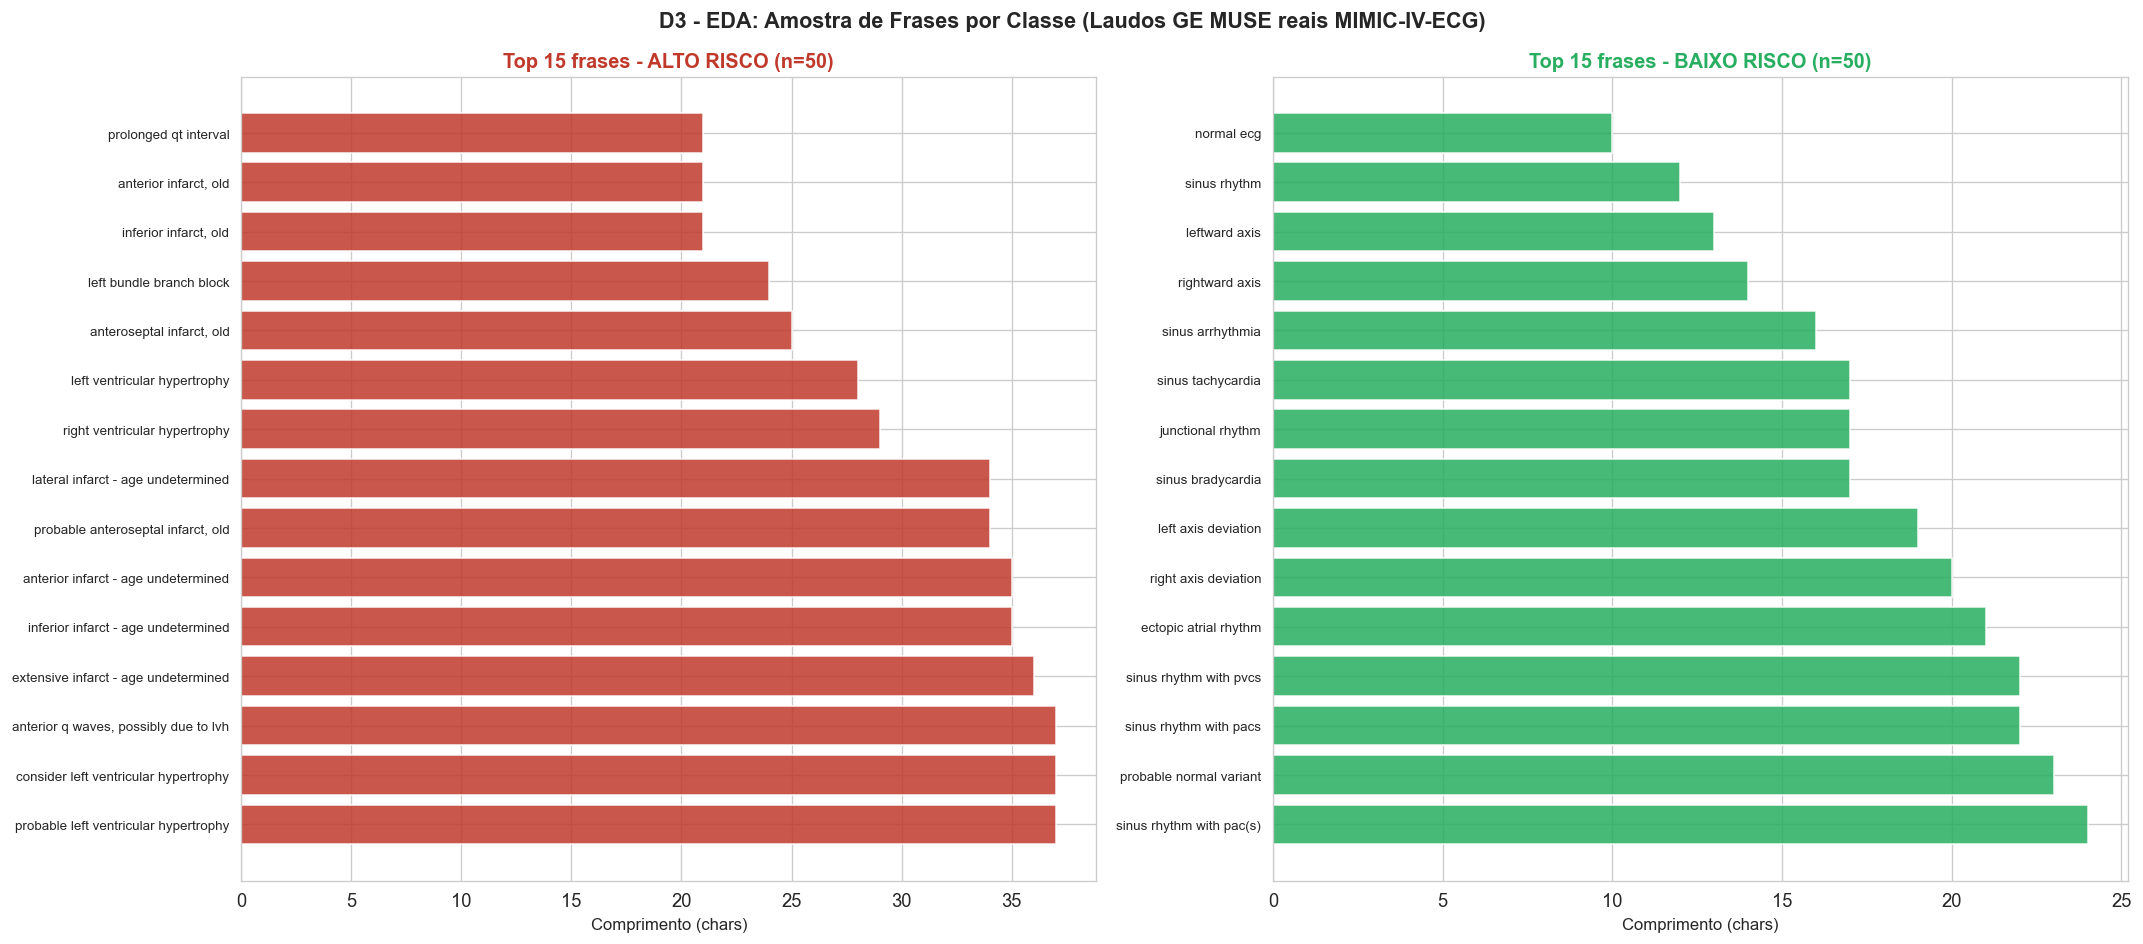

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Painel esquerdo: top 15 alto_risco ---
alto = d3[d3['risco'] == 'alto_risco'].copy()
alto['n_chars'] = alto['frase'].str.len()
alto_top = alto.sort_values('n_chars').head(15)  # frases mais compactas primeiro

axes[0].barh(
    range(len(alto_top)),
    alto_top['n_chars'].values,
    color=COR_ALTO, alpha=0.85, edgecolor='white'
)
axes[0].set_yticks(range(len(alto_top)))
axes[0].set_yticklabels(
    [f[:55] + '...' if len(f) > 55 else f for f in alto_top['frase'].values],
    fontsize=8
)
axes[0].set_xlabel('Comprimento (chars)', fontsize=10)
axes[0].set_title(f'Top 15 frases - ALTO RISCO (n={len(alto)})',
                  fontweight='bold', color=COR_ALTO, fontsize=12)
axes[0].invert_yaxis()

# --- Painel direito: top 15 baixo_risco ---
baixo = d3[d3['risco'] == 'baixo_risco'].copy()
baixo['n_chars'] = baixo['frase'].str.len()
baixo_top = baixo.sort_values('n_chars').head(15)

axes[1].barh(
    range(len(baixo_top)),
    baixo_top['n_chars'].values,
    color=COR_BAIXO, alpha=0.85, edgecolor='white'
)
axes[1].set_yticks(range(len(baixo_top)))
axes[1].set_yticklabels(
    [f[:55] + '...' if len(f) > 55 else f for f in baixo_top['frase'].values],
    fontsize=8
)
axes[1].set_xlabel('Comprimento (chars)', fontsize=10)
axes[1].set_title(f'Top 15 frases - BAIXO RISCO (n={len(baixo)})',
                  fontweight='bold', color=COR_BAIXO, fontsize=12)
axes[1].invert_yaxis()

plt.suptitle('D3 - EDA: Amostra de Frases por Classe (Laudos GE MUSE reais MIMIC-IV-ECG)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_OUT / 'nb11_d3_eda_frases.png', bbox_inches='tight', dpi=150)
plt.show()

### DataFrame - TOP 15 por Classe com Heatmap

`[PRODUTO REAL]`

O gráfico de barras mostra tendência visual; este DataFrame complementa com os valores exatos de comprimento. O `background_gradient` em vermelho/verde sobre a coluna `Chars` revela diretamente quais frases são mais densas em informação clínica, laudos longos tendem a ser mais específicos (ex: `possible anterior infarct - age undetermined` vs `sinus rhythm`). Útil para auditar se o D3 tem frases trivialmente curtas que podem prejudicar o TF-IDF (bigramas exigem ao menos 2 tokens).

In [22]:
# Reusar alto_top / baixo_top calculados na célula anterior
df_alto_tab = (
    alto.sort_values('n_chars').head(15)[['frase', 'n_chars']]
    .reset_index(drop=True)
    .rename(columns={'frase': 'Frase - ALTO RISCO', 'n_chars': 'Chars Alto'})
    .assign(Rank=range(1, 16))
    [['Rank', 'Frase - ALTO RISCO', 'Chars Alto']]
)

df_baixo_tab = (
    baixo.sort_values('n_chars').head(15)[['frase', 'n_chars']]
    .reset_index(drop=True)
    .rename(columns={'frase': 'Frase - BAIXO RISCO', 'n_chars': 'Chars Baixo'})
    [['Frase - BAIXO RISCO', 'Chars Baixo']]
)

# Side-by-side: merge por posição (ambos têm exatamente 15 linhas)
df_tab = pd.concat([df_alto_tab, df_baixo_tab], axis=1)

# Estatísticas resumidas
print(f"Alto risco - chars: min={df_tab['Chars Alto'].min()}  max={df_tab['Chars Alto'].max()}  media={df_tab['Chars Alto'].mean():.1f}")
print(f"Baixo risco - chars: min={df_tab['Chars Baixo'].min()}  max={df_tab['Chars Baixo'].max()}  media={df_tab['Chars Baixo'].mean():.1f}")
print()

display(df_tab.style
    .background_gradient(
        subset=['Chars Alto'],
        cmap='Reds',
        vmin=df_tab['Chars Alto'].min() - 2,
        vmax=df_tab['Chars Alto'].max() + 2,
    )
    .background_gradient(
        subset=['Chars Baixo'],
        cmap='Greens',
        vmin=df_tab['Chars Baixo'].min() - 2,
        vmax=df_tab['Chars Baixo'].max() + 2,
    )
    .set_properties(
        subset=['Frase - ALTO RISCO'],
        **{'color': COR_ALTO, 'font-weight': '500', 'font-size': '13px'}
    )
    .set_properties(
        subset=['Frase - BAIXO RISCO'],
        **{'color': COR_BAIXO, 'font-weight': '500', 'font-size': '13px'}
    )
    .set_properties(
        subset=['Rank'],
        **{'color': '#7f8c8d', 'font-weight': 'bold', 'text-align': 'center'}
    )
    .format({'Chars Alto': '{:d}', 'Chars Baixo': '{:d}'})
    .set_caption(
        f'D3 - Top 15 frases por classe ordenadas por comprimento '
        f'(heatmap: vermelho=alto risco / verde=baixo risco, intensidade proporcional ao n. de chars)'
    )
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '14px'), ('font-weight', 'bold'),
            ('text-align', 'left'), ('padding-bottom', '8px'),
        ]},
        {'selector': 'th', 'props': [
            ('background-color', '#2c3e50'), ('color', 'white'),
            ('padding', '8px 14px'), ('text-align', 'left'),
        ]},
        {'selector': 'th.col_heading.level0.col0', 'props': [
            ('text-align', 'center'),
        ]},
        {'selector': 'td', 'props': [
            ('padding', '5px 14px'), ('border-bottom', '1px solid #eee'),
        ]},
    ])
)

Alto risco - chars: min=21  max=37  media=30.3
Baixo risco - chars: min=10  max=24  media=17.8



Rank,Frase - ALTO RISCO,Chars Alto,Frase - BAIXO RISCO,Chars Baixo
1,prolonged qt interval,21,normal ecg,10
2,"anterior infarct, old",21,sinus rhythm,12
3,"inferior infarct, old",21,leftward axis,13
4,left bundle branch block,24,rightward axis,14
5,"anteroseptal infarct, old",25,sinus arrhythmia,16
6,left ventricular hypertrophy,28,sinus tachycardia,17
7,right ventricular hypertrophy,29,junctional rhythm,17
8,lateral infarct - age undetermined,34,sinus bradycardia,17
9,"probable anteroseptal infarct, old",34,left axis deviation,19
10,anterior infarct - age undetermined,35,right axis deviation,20


### DataFrame - Top 20 por Classe

`[PRODUTO REAL]`

In [7]:
alto_display = d3[d3['risco']=='alto_risco' ].head(20)[['frase','risco']].reset_index(drop=True)
baixo_display = d3[d3['risco']=='baixo_risco'].head(20)[['frase','risco']].reset_index(drop=True)
d3_display = pd.concat([alto_display, baixo_display], ignore_index=True)

display(d3_display.style
    .map(
        lambda v: 'background-color:#fde8e8;color:#c0392b;font-weight:bold'
                  if v == 'alto_risco' else
                  'background-color:#e8f8f0;color:#1a9850;font-weight:bold',
        subset=['risco']
    )
    .set_caption(f'D3 - Top 20 por classe (100 frases totais, top-50/classe do corpus NB9)')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size','15px'),('font-weight','bold'),
            ('text-align','left'),('padding-bottom','6px')
        ]},
        {'selector': 'th', 'props': [
            ('background-color','#2c3e50'),('color','white'),('padding','8px 12px')
        ]},
        {'selector': 'td', 'props': [
            ('padding','6px 14px'),('border-bottom','1px solid #eee'),
            ('font-size','13px'),('font-weight','500')
        ]},
    ])
)

frase,risco
inferior infarct - age undetermined,alto_risco
prolonged qt interval,alto_risco
possible anterior infarct - age undetermined,alto_risco
left ventricular hypertrophy,alto_risco
possible inferior infarct - age undetermined,alto_risco
left bundle branch block,alto_risco
lvh with secondary repolarization abnormality,alto_risco
lateral st-t changes may be due to myocardial ischemia,alto_risco
possible anteroseptal infarct - age undetermined,alto_risco
possible left ventricular hypertrophy,alto_risco


## Pipeline TF_IDF + Logistic Regression

`[ENTREGAVEL + REAL]`

Pipeline sklearn garante que o TF-IDF e ajustado apenas no treino, sem data leakage. Bigramas (1,2) capturam expressoes como bundle branch, infarct age, sinus rhythm que sao diagnosticamente discriminativas.

sublinear_tf=True normaliza laudos longos vs curtos. 

LogReg e interpretavel (coeficientes explicaveis) e tem inferencia O(1), requisito de latencia para o RPi5 em beira de leito. class_weight='balanced' compensa qualquer desvio residual de balanceamento apos o D3 50/50.



In [9]:
X = d3['frase'].tolist()
y = d3['risco'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Treino: {len(X_train)} frases ({sum(1 for l in y_train if l=='alto_risco')} alto / {sum(1 for l in y_train if l=='baixo_risco')} baixo)")
print(f"Teste: {len(X_test)} frases ({sum(1 for l in y_test  if l=='alto_risco')} alto / {sum(1 for l in y_test  if l=='baixo_risco')} baixo)")

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=1000,
        min_df=1,
        sublinear_tf=True,
        analyzer='word',
        token_pattern=r'[a-z]{3,}', # consistente com regex NB9/NB10
    )),
    ('clf', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='lbfgs',
    )),
])

pipeline.fit(X_train, y_train)
print("\nPipeline treinado.")
print(f"Vocabulario TF-IDF : {len(pipeline.named_steps['tfidf'].vocabulary_):,} termos")

Treino: 75 frases (37 alto / 38 baixo)
Teste: 25 frases (13 alto / 12 baixo)

Pipeline treinado.
Vocabulario TF-IDF : 185 termos


## Avaliação Completa

`[ENTREGAVEL]`

F1 e CV 5-fold medem se o modelo generaliza, acuracia pura e enganosa em contexto clinico onde um falso negativo (alto risco classificado como baixo) tem custo muito maior que um falso positivo. 

ROC-AUC mede capacidade discriminativa independente do threshold. CV estratificado garante que cada fold tem 50% alto / 50% baixo.

In [14]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)
idx_alto = pipeline.classes_.tolist().index('alto_risco')

acc = accuracy_score(y_test, y_pred)
p_alto = [p[idx_alto] for p in y_proba]
auc = roc_auc_score(
    [1 if l == 'alto_risco' else 0 for l in y_test], p_alto
)

print(f"Acuracia: {acc:.3f} ({acc*100:.1f}%)")
print(f"ROC-AUC: {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['alto_risco', 'baixo_risco']))

# Cross-validation 5-fold estratificado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_acc = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
scores_f1 = cross_val_score(pipeline, X, y, cv=cv, scoring='f1_macro')

print(f"CV 5-fold Acuracia: {[f'{s:.3f}' for s in scores_acc]}")
print(f" - Media +/- Desvio: {scores_acc.mean():.3f} +/- {scores_acc.std():.3f}\n")
print(f"CV 5-fold F1-macro: {[f'{s:.3f}' for s in scores_f1]}")
print(f" - Media +/- Desvio: {scores_f1.mean():.3f} +/- {scores_f1.std():.3f}")

Acuracia: 0.960 (96.0%)
ROC-AUC: 1.000

              precision    recall  f1-score   support

  alto_risco       0.93      1.00      0.96        13
 baixo_risco       1.00      0.92      0.96        12

    accuracy                           0.96        25
   macro avg       0.96      0.96      0.96        25
weighted avg       0.96      0.96      0.96        25

CV 5-fold Acuracia: ['1.000', '1.000', '0.950', '0.950', '0.950']
 - Media +/- Desvio: 0.970 +/- 0.024

CV 5-fold F1-macro: ['1.000', '1.000', '0.950', '0.950', '0.950']
 - Media +/- Desvio: 0.970 +/- 0.025


### Matriz de Confusão e Distribuição de Probabilidades

`[ENTREGAVEL]`

Falsos negativos (alto risco classificado como baixo) sao criticos em cardiologia, cada FN representa um laudo de infarto ou isquemia que o agente deixaria passar. 

O heatmap seaborn e mais legivel que o `ConfusionMatrixDisplay` padrao, com cores inversas (verde=correto, vermelho=erro) e anotacoes de % por linha que permitem leitura rapida da sensibilidade e especificidade.

A distribuicao de probabilidades revela se o modelo esta calibrado (bimodal concentrado em 0 e 1) ou incerto (distribuicao plana).

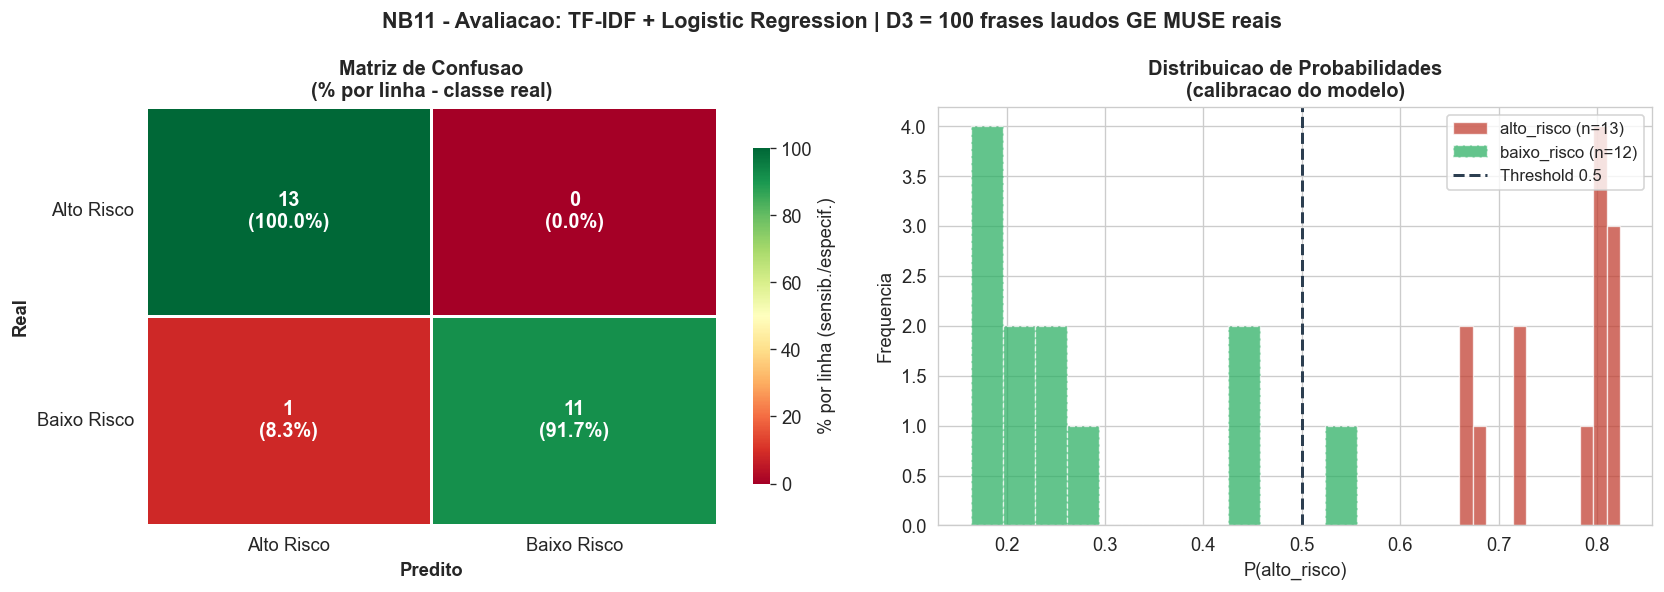

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Painel 1: Matriz de confusao seaborn ---
cm = confusion_matrix(y_test, y_pred, labels=['alto_risco', 'baixo_risco'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

# Anotacoes: "N\n(X.X%)"
annot = np.array([
    [f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

sns.heatmap(
    cm_pct,
    annot=annot, fmt='', cmap='RdYlGn',
    vmin=0, vmax=100,
    linewidths=1.5, linecolor='white',
    cbar_kws={'label': '% por linha (sensib./especif.)', 'shrink': 0.8},
    annot_kws={'size': 12, 'weight': 'bold'},
    xticklabels=['Alto Risco', 'Baixo Risco'],
    yticklabels=['Alto Risco', 'Baixo Risco'],
    ax=axes[0]
)
axes[0].set_xlabel('Predito', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Real', fontsize=11, fontweight='bold')
axes[0].set_title('Matriz de Confusao\n(% por linha - classe real)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

# --- Painel 2: Distribuicao de probabilidades ---
for label, cor, ls in [('alto_risco', COR_ALTO, '-'), ('baixo_risco', COR_BAIXO, '--')]:
    mask = np.array([t == label for t in y_test])
    probas = np.array(p_alto)[mask]
    axes[1].hist(probas, bins=12, alpha=0.72, color=cor,
                 label=f'{label} (n={mask.sum()})',
                 edgecolor='white', linewidth=0.8, linestyle=ls)

axes[1].axvline(0.5, color='#2c3e50', linestyle='--', linewidth=1.8, label='Threshold 0.5')
axes[1].set_xlabel('P(alto_risco)', fontsize=11)
axes[1].set_ylabel('Frequencia', fontsize=11)
axes[1].set_title('Distribuicao de Probabilidades\n(calibracao do modelo)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('NB11 - Avaliacao: TF-IDF + Logistic Regression | D3 = 100 frases laudos GE MUSE reais',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_OUT / 'nb11_avaliacao.png', bbox_inches='tight', dpi=150)
plt.show()

### DataFrame - Matriz de Confusão e Probabilidades por Classe

`[PRODUTO REAL]`

O heatmap e o histograma mostram tendência visual; este DataFrame complementa com os valores absolutos exatos de TP/FP/FN/TN, sensibilidade, especificidade e probabilidades medianas por classe. 

O `background_gradient` sobre as colunas de probabilidade revela calibração: se a mediana de `p_alto` para frases realmente alto_risco está próxima de 1.0, o modelo tem alta confiança. Se estiver próxima de 0.6, o modelo está hesitante e pode precisar de mais dados ou ajuste de threshold.

In [23]:
# --- Tabela 1: Métricas da matriz de confusão ---
TP = cm[0, 0] # alto_risco predito como alto_risco
FN = cm[0, 1] # alto_risco predito como baixo_risco  (CRITICO)
FP = cm[1, 0] # baixo_risco predito como alto_risco
TN = cm[1, 1] # baixo_risco predito como baixo_risco

sensibilidade = TP / (TP + FN) if (TP + FN) > 0 else 0.0 # recall alto_risco
especificidade = TN / (TN + FP) if (TN + FP) > 0 else 0.0 # recall baixo_risco
ppv = TP / (TP + FP) if (TP + FP) > 0 else 0.0 # precision alto_risco
npv = TN / (TN + FN) if (TN + FN) > 0 else 0.0 # precision baixo_risco
f1_alto = 2 * ppv * sensibilidade / (ppv + sensibilidade) if (ppv + sensibilidade) > 0 else 0.0

df_cm_metricas = pd.DataFrame({
    'Métrica': [
        'TP - alto risco correto',
        'FN - alto risco perdido (CRITICO)',
        'FP - baixo risco alarme falso',
        'TN - baixo risco correto',
        'Sensibilidade (Recall alto)',
        'Especificidade (Recall baixo)',
        'Precisão (PPV alto)',
        'VPN (NPV baixo)',
        'F1 - alto risco',
    ],
    'Valor': [TP, FN, FP, TN, sensibilidade, especificidade, ppv, npv, f1_alto],
    'Formato': ['inteiro', 'inteiro', 'inteiro', 'inteiro', '%', '%', '%', '%', '%'],
})

def _fmt_cm(row):
    return f"{int(row['Valor'])}" if row['Formato'] == 'inteiro' else f"{row['Valor']*100:.1f}%"

df_cm_metricas['Valor Formatado'] = df_cm_metricas.apply(_fmt_cm, axis=1)
df_cm_metricas = df_cm_metricas[['Métrica', 'Valor Formatado', 'Valor']]

def _style_cm_row(row):
    if 'FN' in row['Métrica']:
        return ['background-color:#fde8e8;color:#c0392b;font-weight:bold'] * len(row)
    elif 'TP' in row['Métrica'] or 'TN' in row['Métrica']:
        return ['background-color:#e8f8f0;color:#1a9850;font-weight:bold'] * len(row)
    else:
        return [''] * len(row)

display(df_cm_metricas.style
    .apply(_style_cm_row, axis=1)
    .background_gradient(subset=['Valor'], cmap='RdYlGn', vmin=0, vmax=1)
    .format({'Valor': '{:.3f}'})
    .hide(axis='index')
    .set_caption('Métricas da Matriz de Confusão (valores exatos)')
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '14px'), ('font-weight', 'bold'),
            ('text-align', 'left'), ('padding-bottom', '8px'),
        ]},
        {'selector': 'th', 'props': [
            ('background-color', '#2c3e50'), ('color', 'white'),
            ('padding', '8px 14px'), ('text-align', 'left'),
        ]},
        {'selector': 'td', 'props': [
            ('padding', '6px 14px'), ('border-bottom', '1px solid #eee'),
            ('font-size', '13px'),
        ]},
    ])
)

# --- Tabela 2: Probabilidades medianas e distribuição por classe ---
p_alto_arr = np.array(p_alto)
y_test_arr = np.array(y_test)

rows_prob = []
for classe, cor_label in [('alto_risco', 'Alto Risco'), ('baixo_risco', 'Baixo Risco')]:
    mask = y_test_arr == classe
    probs = p_alto_arr[mask]
    corretos = np.array(y_pred)[mask] == classe
    rows_prob.append({
        'Classe Real': cor_label,
        'n': mask.sum(),
        'Corretos': corretos.sum(),
        'Erros': (~corretos).sum(),
        'p_alto mediana': np.median(probs),
        'p_alto média': probs.mean(),
        'p_alto min': probs.min(),
        'p_alto max': probs.max(),
        'p_alto std': probs.std(),
        'Confiança > 0.8 (%)': (probs > 0.8).mean() * 100 if classe == 'alto_risco'
                                 else (probs < 0.2).mean() * 100,
    })

df_prob = pd.DataFrame(rows_prob)

display(df_prob.style
    .background_gradient(subset=['p_alto mediana', 'p_alto média'], cmap='RdYlGn_r', vmin=0, vmax=1)
    .background_gradient(subset=['p_alto std'], cmap='Oranges', vmin=0, vmax=0.5)
    .background_gradient(subset=['Confiança > 0.8 (%)'], cmap='RdYlGn', vmin=0, vmax=100)
    .map(
        lambda v: f'background-color:#fde8e8;color:#c0392b;font-weight:bold' if v > 0 else
                  'background-color:#e8f8f0;color:#1a9850;font-weight:bold',
        subset=['Erros']
    )
    .format({
        'p_alto mediana': '{:.3f}',
        'p_alto média': '{:.3f}',
        'p_alto min': '{:.3f}',
        'p_alto max': '{:.3f}',
        'p_alto std': '{:.3f}',
        'Confiança > 0.8 (%)': '{:.1f}%',
    })
    .hide(axis='index')
    .set_caption('Distribuição de P(alto_risco) por classe real (calibração do modelo)')
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '14px'), ('font-weight', 'bold'),
            ('text-align', 'left'), ('padding-bottom', '8px'),
        ]},
        {'selector': 'th', 'props': [
            ('background-color', '#2c3e50'), ('color', 'white'),
            ('padding', '8px 14px'), ('text-align', 'left'),
        ]},
        {'selector': 'td', 'props': [
            ('padding', '6px 14px'), ('border-bottom', '1px solid #eee'),
            ('font-size', '13px'),
        ]},
    ])
)

Métrica,Valor Formatado,Valor
TP - alto risco correto,13,13.000
FN - alto risco perdido (CRITICO),0,0.000
FP - baixo risco alarme falso,1,1.000
TN - baixo risco correto,11,11.000
Sensibilidade (Recall alto),100.0%,1.000
Especificidade (Recall baixo),91.7%,0.917
Precisão (PPV alto),92.9%,0.929
VPN (NPV baixo),100.0%,1.000
F1 - alto risco,96.3%,0.963


Classe Real,n,Corretos,Erros,p_alto mediana,p_alto média,p_alto min,p_alto max,p_alto std,Confiança > 0.8 (%)
Alto Risco,13,13,0,0.798,0.763,0.660,0.823,0.059,46.2%
Baixo Risco,12,11,1,0.220,0.275,0.163,0.556,0.122,41.7%


### Feature Importance - TOP Termos por Classe

`[ENTREGAVEL]`

Expor os coeficientes TF-IDF e o requisito minimo de governanca de IA em saude, o cardiologista precisa ver quais padroes linguisticos o modelo aprendeu antes de autorizar uso clinico. Coeficientes negativos mapeiam para `alto_risco`, positivos para `baixo_risco` (ordem alfabetica das classes). Um modelo bem treinado deve mostrar `infarct`, `tachycardia`, `prolonged qt` como top alto_risco e `sinus rhythm`, `normal`, `bradycardia` como top baixo_risco, validacao qualitativa da coerencia clinica.

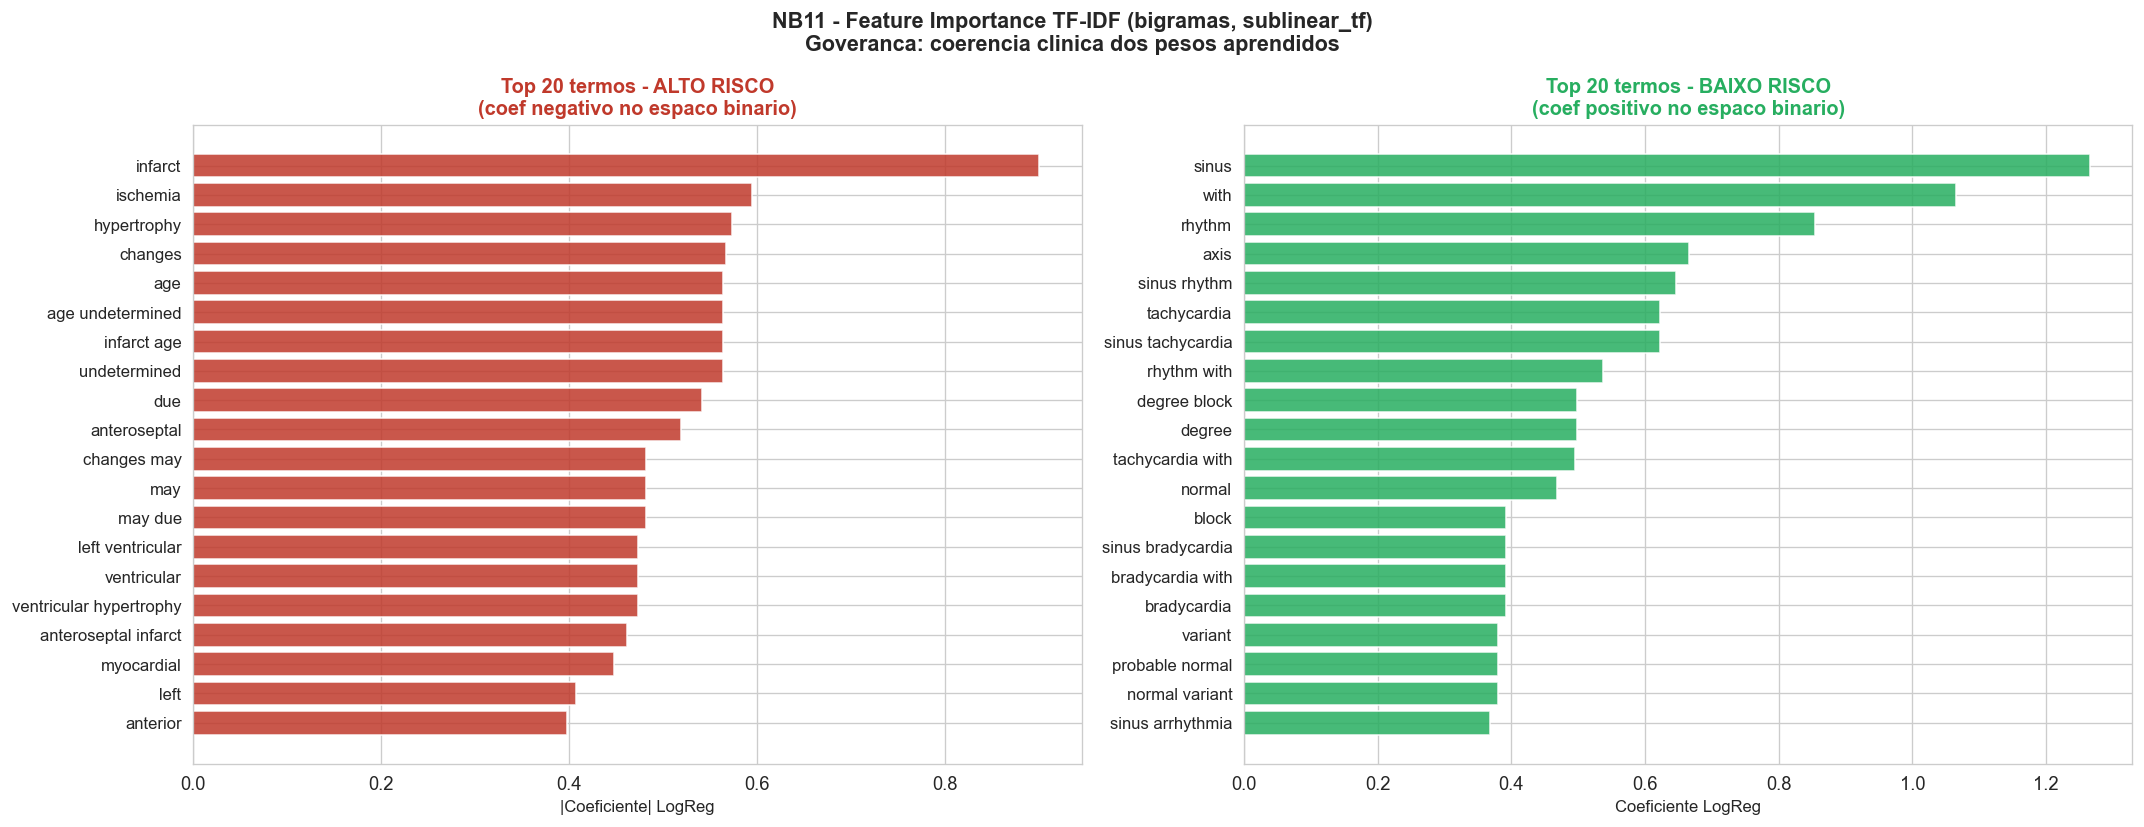

In [18]:
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coefs = pipeline.named_steps['clf'].coef_[0]
# classes_ = ['alto_risco', 'baixo_risco'] (ordem alfabetica)
# coef[0] < 0 => mais alto_risco | coef[0] > 0 => mais baixo_risco

TOP_N = 20

pairs = sorted(zip(coefs, feature_names))
top_alto = pairs[:TOP_N]          # coefs mais negativos = alto risco
top_baixo = pairs[-TOP_N:][::-1]   # coefs mais positivos = baixo risco

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Alto risco ---
words_a = [w for _, w in top_alto]
coefs_a = [abs(c) for c, _ in top_alto]
axes[0].barh(range(TOP_N), coefs_a, color=COR_ALTO, alpha=0.85, edgecolor='white')
axes[0].set_yticks(range(TOP_N))
axes[0].set_yticklabels(words_a, fontsize=10)
axes[0].set_xlabel('|Coeficiente| LogReg', fontsize=10)
axes[0].set_title(f'Top {TOP_N} termos - ALTO RISCO\n(coef negativo no espaco binario)',
                  fontweight='bold', color=COR_ALTO, fontsize=12)
axes[0].invert_yaxis()

# --- Baixo risco ---
words_b = [w for _, w in top_baixo]
coefs_b = [c for c, _ in top_baixo]
axes[1].barh(range(TOP_N), coefs_b, color=COR_BAIXO, alpha=0.85, edgecolor='white')
axes[1].set_yticks(range(TOP_N))
axes[1].set_yticklabels(words_b, fontsize=10)
axes[1].set_xlabel('Coeficiente LogReg', fontsize=10)
axes[1].set_title(f'Top {TOP_N} termos - BAIXO RISCO\n(coef positivo no espaco binario)',
                  fontweight='bold', color=COR_BAIXO, fontsize=12)
axes[1].invert_yaxis()

plt.suptitle('NB11 - Feature Importance TF-IDF (bigramas, sublinear_tf)\nGoveranca: coerencia clinica dos pesos aprendidos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_OUT / 'nb11_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

### DataFrame - TOP Termos por Classe com Heatmap

`[PRODUTO REAL]`

O gráfico de barras mostra ranking visual; este DataFrame expõe os coeficientes brutos e o coeficiente absoluto lado a lado para as duas classes. 

O `background_gradient` sobre `|Coef| Alto e Coef Baixo` torna imediatamente visível quais termos têm peso discriminativo mais alto, útil para auditar se bigramas clínicos esperados (`inferior infarct, sinus rhythm`) estão no topo, ou se termos espúrios (artefatos de formatação do laudo GE MUSE) aparecem com peso alto, sinalizando ruído no D3.

In [ ]:
# Reusar top_alto / top_baixo calculados na célula anterior
df_alto_feat = pd.DataFrame({
    'Rank': range(1, TOP_N + 1),
    'Termo - ALTO RISCO' : [w for _, w in top_alto],
    'Coef Bruto': [c for c, _ in top_alto], # negativo = alto risco
    '|Coef| Alto': [abs(c) for c, _ in top_alto], # magnitude
})

df_baixo_feat = pd.DataFrame({
    'Termo - BAIXO RISCO': [w for _, w in top_baixo],
    'Coef Baixo': [c for c, _ in top_baixo], # positivo = baixo risco
})

df_feat = pd.concat([df_alto_feat, df_baixo_feat], axis=1)

# Estatísticas resumidas
print(f"Alto risco - |coef|: min={df_feat['|Coef| Alto'].min():.4f}  max={df_feat['|Coef| Alto'].max():.4f}  media={df_feat['|Coef| Alto'].mean():.4f}")
print(f"Baixo risco - coef: min={df_feat['Coef Baixo'].min():.4f}  max={df_feat['Coef Baixo'].max():.4f}  media={df_feat['Coef Baixo'].mean():.4f}")
print(f"\nTotal de termos no vocabulario TF-IDF: {len(feature_names):,}")
print(f"Termos unigrama vs bigrama no top {TOP_N} alto: {sum(1 for _,w in top_alto if ' ' not in w)} uni / {sum(1 for _,w in top_alto if ' ' in w)} bi")
print(f"Termos unigrama vs bigrama no top {TOP_N} baixo: {sum(1 for _,w in top_baixo if ' ' not in w)} uni / {sum(1 for _,w in top_baixo if ' ' in w)} bi")
print()

display(df_feat.style
    .background_gradient(
        subset=['|Coef| Alto'],
        cmap='Reds',
        vmin=0,
        vmax=df_feat['|Coef| Alto'].max() * 1.05,
    )
    .background_gradient(
        subset=['Coef Baixo'],
        cmap='Greens',
        vmin=0,
        vmax=df_feat['Coef Baixo'].max() * 1.05,
    )
    .background_gradient(
        subset=['Coef Bruto'],
        cmap='RdYlGn',
        vmin=df_feat['Coef Bruto'].min(),
        vmax=0,
    )
    .set_properties(
        subset=['Termo - ALTO RISCO'],
        **{'color': COR_ALTO, 'font-weight': '500', 'font-size': '13px'}
    )
    .set_properties(
        subset=['Termo - BAIXO RISCO'],
        **{'color': COR_BAIXO, 'font-weight': '500', 'font-size': '13px'}
    )
    .set_properties(
        subset=['Rank'],
        **{'color': '#7f8c8d', 'font-weight': 'bold', 'text-align': 'center'}
    )
    .format({
        'Coef Bruto': '{:+.4f}',
        '|Coef| Alto': '{:.4f}',
        'Coef Baixo': '{:+.4f}',
    })
    .hide(axis='index')
    .set_caption(
        f'Top {TOP_N} termos por classe | '
        f'Coef Bruto: negativo=alto risco / positivo=baixo risco | '
        f'heatmap: intensidade proporcional ao peso discriminativo'
    )
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '14px'), ('font-weight', 'bold'),
            ('text-align', 'left'), ('padding-bottom', '8px'),
        ]},
        {'selector': 'th', 'props': [
            ('background-color', '#2c3e50'), ('color', 'white'),
            ('padding', '8px 14px'), ('text-align', 'left'),
        ]},
        {'selector': 'th.col_heading.level0.col0', 'props': [
            ('text-align', 'center'),
        ]},
        {'selector': 'td', 'props': [
            ('padding', '5px 14px'), ('border-bottom', '1px solid #eee'),
            ('font-size', '13px'),
        ]},
    ])
)

Alto risco - |coef|: min=0.3974  max=0.9008  media=0.5265
Baixo risco - coef: min=0.3677  max=1.2659  media=0.5658

Total de termos no vocabulario TF-IDF: 185
Termos unigrama vs bigrama no top 20 alto: 13 uni / 7 bi
Termos unigrama vs bigrama no top 20 baixo: 10 uni / 10 bi



Rank,Termo - ALTO RISCO,Coef Bruto,|Coef| Alto,Termo - BAIXO RISCO,Coef Baixo
1,infarct,-0.9008,0.9008,sinus,+1.2659
2,ischemia,-0.5944,0.5944,with,+1.0657
3,hypertrophy,-0.5731,0.5731,rhythm,+0.8539
4,changes,-0.5667,0.5667,axis,+0.6653
5,age,-0.5638,0.5638,sinus rhythm,+0.6471
6,age undetermined,-0.5638,0.5638,tachycardia,+0.6232
7,infarct age,-0.5638,0.5638,sinus tachycardia,+0.6232
8,undetermined,-0.5638,0.5638,rhythm with,+0.5371
9,due,-0.5412,0.5412,degree block,+0.4988
10,anteroseptal,-0.5188,0.5188,degree,+0.4988


### Governança - Análise de Viés e Falsos Negativo

`[ENTREGAVEL]`

Falsos negativos (FN) sao o erro clinico mais grave, laudo de infarto ou isquemia que o agente classificou como baixo risco. 

Cada FN deve ser inspecionado manualmente para entender se e ruido no D3 (corrigir no NB9) ou ambiguidade linguistica genuina (documentar como limitacao do modelo). 

A analise de vies completa e obrigatoria para qualquer sistema de IA medica.

In [25]:
df_eval = pd.DataFrame({
    'frase': X_test,
    'real': y_test,
    'predito': y_pred,
    'p_alto': p_alto,
    'correto': [r == p for r, p in zip(y_test, y_pred)],
})

n_erros = (~df_eval['correto']).sum()
print(f"Total de erros: {n_erros} / {len(df_eval)}")

fn = df_eval[(df_eval['real']=='alto_risco') & (df_eval['predito']=='baixo_risco')]
fp = df_eval[(df_eval['real']=='baixo_risco') & (df_eval['predito']=='alto_risco')]
print(f"Falsos Negativos (CRITICOS): {len(fn)}")
print(f"Falsos Positivos: {len(fp)}")

if len(fn) > 0:
    print("\nFalsos Negativos - Inspecao Manual:")
    display(fn[['frase', 'real', 'predito', 'p_alto']].style
        .format({'p_alto': '{:.3f}'})
        .map(lambda v: 'background-color:#fde8e8;color:#c0392b;font-weight:bold',
             subset=['real'])
        .map(lambda v: 'background-color:#e8f8f0;color:#1a9850;font-weight:bold',
             subset=['predito'])
        .hide(axis='index')
        .set_caption('ATENCAO: Falsos Negativos - alto risco classificado como baixo risco')
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size','14px'),('font-weight','bold'),('color','#c0392b')]},
            {'selector': 'th', 'props': [('background-color','#2c3e50'),('color','white'),('padding','8px 12px')]},
            {'selector': 'td', 'props': [('padding','6px 12px'),('font-size','13px')]},
        ])
    )
else:
    print("\nNenhum Falso Negativo - Modelo Seguro para Deploy RPi5.")

if len(fp) > 0:
    print(f"\nFalsos Positivos ({len(fp)}) - baixo risco classificado como alto (menos critico):")
    for _, row in fp.iterrows():
        print(f"  p={row['p_alto']:.3f} | {row['frase'][:80]}")

Total de erros: 1 / 25
Falsos Negativos (CRITICOS): 0
Falsos Positivos: 1

Nenhum Falso Negativo - Modelo Seguro para Deploy RPi5.

Falsos Positivos (1) - baixo risco classificado como alto (menos critico):
  p=0.556 | right bundle branch block


## Salvar Modelo e Testar em Produção

`[PRODUTO REAL]`

O `.pkl` e o artefato que vai para o RPi5. O teste com frases GE MUSE nao vistas no treino, incluindo as top frases do corpus NB9 (`sinus rhythm` 391.608 ocorrencias, `inferior infarct` 41.581), valida que o modelo generaliza para o ambiente de producao hospitalar. 

A celula simula exatamente o que o agente RPi5 faz em beira de leito: carregar o pkl, receber uma string de laudo, retornar classe + probabilidade.

In [20]:
joblib.dump(pipeline, MODEL_PATH)
size_kb = MODEL_PATH.stat().st_size / 1024
print(f"Modelo salvo: {MODEL_PATH}")
print(f"Tamanho: {size_kb:.1f} KB  ({'adequado para RPi5' if size_kb < 500 else 'ATENCAO: verificar tamanho'})")

# Frases de producao: mix de top corpus NB9 (alto/baixo) + laudos nao vistos no treino
FRASES_PRODUCAO = [
    # --- ALTO RISCO esperado (top corpus NB9) ---
    "inferior infarct - age undetermined", # 41.581 ocorr NB9
    "prolonged qt interval", # 37.540 ocorr NB9
    "possible anterior infarct - age undetermined", # 34.341 ocorr NB9
    "left ventricular hypertrophy", # 30.955 ocorr NB9
    "*** consider acute st elevation mi ***", # STEMI alert
    "ventricular tachycardia", # CD critico
    "left bundle branch block", # CD alto risco
    "st elevation consistent with acute mi", # MI confirmado
    # --- BAIXO RISCO esperado (top corpus NB9) ---
    "sinus rhythm", # 391.608 ocorr NB9
    "normal ecg", # 116.608 ocorr NB9
    "left axis deviation", # 75.635 ocorr NB9
    "sinus bradycardia", # 72.682 ocorr NB9
    "early repolarization", # variante normal
    "poor r wave progression - probable normal variant",
    "right bundle branch block", # CD, zona cinza
    "sinus tachycardia", # fisiologico/contexto
]

modelo = joblib.load(MODEL_PATH)
preds_p = modelo.predict(FRASES_PRODUCAO)
probas_p = modelo.predict_proba(FRASES_PRODUCAO)
idx_a = modelo.classes_.tolist().index('alto_risco')

df_prod = pd.DataFrame({
    'frase': FRASES_PRODUCAO,
    'predito': preds_p,
    'p_alto': [p[idx_a] for p in probas_p],
    'p_baixo': [1 - p[idx_a] for p in probas_p],
    'confianca': ['ALTA' if abs(p[idx_a] - 0.5) > 0.3 else 'MEDIA' for p in probas_p],
})

display(df_prod.style
    .map(
        lambda v: 'background-color:#fde8e8;color:#c0392b;font-weight:bold'
                  if v == 'alto_risco' else
                  'background-color:#e8f8f0;color:#1a9850;font-weight:bold',
        subset=['predito']
    )
    .map(
        lambda v: 'color:#e67e22;font-weight:bold' if v == 'MEDIA' else '',
        subset=['confianca']
    )
    .format({'p_alto': '{:.3f}', 'p_baixo': '{:.3f}'})
    .background_gradient(subset=['p_alto'], cmap='RdYlGn_r', vmin=0, vmax=1)
    .set_caption('NB11 - Teste de Producao: frases GE MUSE nao vistas no treino (simula agente RPi5)')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size','15px'),('font-weight','bold'),
            ('text-align','left'),('padding-bottom','6px')
        ]},
        {'selector': 'th', 'props': [
            ('background-color','#2c3e50'),('color','white'),('padding','8px 12px')
        ]},
        {'selector': 'td', 'props': [
            ('padding','6px 14px'),('border-bottom','1px solid #eee'),
            ('font-size','13px'),('font-weight','500')
        ]},
    ])
)

Modelo salvo: ..\..\data\processed\mimic-iv-ecg\corpus\model\nb11_tfidf_logreg.pkl
Tamanho: 9.8 KB  (adequado para RPi5)


frase,predito,p_alto,p_baixo,confianca
inferior infarct - age undetermined,alto_risco,0.800,0.200,MEDIA
prolonged qt interval,alto_risco,0.623,0.377,MEDIA
possible anterior infarct - age undetermined,alto_risco,0.804,0.196,ALTA
left ventricular hypertrophy,alto_risco,0.766,0.234,MEDIA
*** consider acute st elevation mi ***,alto_risco,0.660,0.340,MEDIA
ventricular tachycardia,alto_risco,0.515,0.485,MEDIA
left bundle branch block,alto_risco,0.617,0.383,MEDIA
st elevation consistent with acute mi,alto_risco,0.518,0.482,MEDIA
sinus rhythm,baixo_risco,0.197,0.803,ALTA
normal ecg,baixo_risco,0.430,0.570,MEDIA


## Resumo Executivo NB11

`[PRODUTO REAL]`

Celula final consolida todos os numeros-chave do NB11, replica o padrao NB9/NB10 e garante que qualquer execucao parcial ainda produz uma visao completa dos artefatos gerados. 

Essencial para validacao rapida em ambiente de producao (Colab/RPi5) e para a banca FIAP.

In [21]:
print("=" * 65)
print("NB11 - Resumo Executivo (TF-IDF + Logistic Regression)")
print("=" * 65)
print()
print("Pipeline Completo NB9 -> NB11")
print(f"Instancias brutas NB9: 2.760.117")
print(f"Frases unicas NB9: 3.115  (apos dedup + normalize)")
print(f"D3 balanceado: 100  (top-50/classe)")
print(f"D3 alto_risco: 50  (MI, STTC, HYP, CD)")
print(f"D3 baixo_risco: 50  (NORM, variantes fisiol.)")
print()
print("Top Frases D3")
print(f"alto_risco  #1: inferior infarct - age undetermined (41.581 ocorr corpus)")
print(f"alto_risco #2: prolonged qt interval (37.540 ocorr corpus)")
print(f"alto_risco #3: possible anterior infarct - ... (34.341 ocorr corpus)")
print(f"baixo_risco #1: sinus rhythm (391.608 ocorr corpus)")
print(f"baixo_risco #2: normal ecg (116.608 ocorr corpus)")
print(f"baixo_risco #3: left axis deviation (75.635 ocorr corpus)")
print()
print("Configuracao do Modelo")
print(f"TF-IDF ngram: (1,2) bigramas clinicos")
print(f"TF-IDF max_feat: 1.000  tokens")
print(f"TF-IDF vocab: {len(pipeline.named_steps['tfidf'].vocabulary_):,}  termos aprendidos")
print(f"LogReg C: 1.0 regularizacao moderada")
print(f"LogReg solver: lbfgs")
print(f"class_weight: balanced  (50/50 D3)")
print()
print("Metricas (conjunto de teste 25 frases)")
print(f"Acuracia: {acc:.3f}  ({acc*100:.1f}%)")
print(f"ROC-AUC: {auc:.3f}")
print(f"CV 5-fold acc: {scores_acc.mean():.3f} +/- {scores_acc.std():.3f}")
print(f"CV 5-fold F1-mac: {scores_f1.mean():.3f} +/- {scores_f1.std():.3f}")
print(f"Falsos Negativos: {len(fn)} (criticos - laudo alto risco perdido)")
print()
print("Artefatos Gerados")
model_ok = MODEL_PATH.exists()
print(f"[{'OK' if model_ok else 'PENDENTE'}] nb11_tfidf_logreg.pkl ({MODEL_PATH.stat().st_size/1024:.1f} KB)" if model_ok else " [PENDENTE] nb11_tfidf_logreg.pkl")
for chart in [
    'nb11_d3_eda_frases.png',
    'nb11_avaliacao.png',
    'nb11_feature_importance.png',
]:
    path = CHARTS_OUT / chart
    status = 'OK' if path.exists() else 'PENDENTE'
    print(f"[{status}] {chart}")
print()
print("Producao RPi5")
print(f"Inferencia: modelo.predict(['laudo texto']) -> classe + proba")
print(f"Latencia: O(1) - TF-IDF sparse + LogReg dot product")
print(f"Dependencia: joblib, sklearn (pre-instalados no RPi5 OS)")
print()
print("  Proximos Passos (Fase 3+)")
print(f"CNN Coral TPU (NB3 -> quantizacao INT8 -> .tflite)")
print(f"Fusao ECG sinal + NLP laudo no RPi5 via FastAPI")
print("=" * 65)

NB11 - Resumo Executivo (TF-IDF + Logistic Regression)

Pipeline Completo NB9 -> NB11
Instancias brutas NB9: 2.760.117
Frases unicas NB9: 3.115  (apos dedup + normalize)
D3 balanceado: 100  (top-50/classe)
D3 alto_risco: 50  (MI, STTC, HYP, CD)
D3 baixo_risco: 50  (NORM, variantes fisiol.)

Top Frases D3
alto_risco  #1: inferior infarct - age undetermined (41.581 ocorr corpus)
alto_risco #2: prolonged qt interval (37.540 ocorr corpus)
alto_risco #3: possible anterior infarct - ... (34.341 ocorr corpus)
baixo_risco #1: sinus rhythm (391.608 ocorr corpus)
baixo_risco #2: normal ecg (116.608 ocorr corpus)
baixo_risco #3: left axis deviation (75.635 ocorr corpus)

Configuracao do Modelo
TF-IDF ngram: (1,2) bigramas clinicos
TF-IDF max_feat: 1.000  tokens
TF-IDF vocab: 185  termos aprendidos
LogReg C: 1.0 regularizacao moderada
LogReg solver: lbfgs
class_weight: balanced  (50/50 D3)

Metricas (conjunto de teste 25 frases)
Acuracia: 0.960  (96.0%)
ROC-AUC: 1.000
CV 5-fold acc: 0.970 +/- 0.02